In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
movies = pd.read_csv('/Users/dhruvitjalodhara/programming/ML Practice/Movie Recommendation System/movie dataset/raw/movies.csv')
ratings = pd.read_csv('/Users/dhruvitjalodhara/programming/ML Practice/Movie Recommendation System/movie dataset/raw/ratings.csv')
tags = pd.read_csv('/Users/dhruvitjalodhara/programming/ML Practice/Movie Recommendation System/movie dataset/raw/tags.csv')

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [5]:
tags.head()

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [6]:
movies.shape , ratings.shape , tags.shape

((86537, 3), (33832162, 4), (2328315, 4))

In [7]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [8]:
movies.duplicated().sum()

np.int64(0)

In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [10]:
movies.movieId = movies.movieId.astype('int32')

In [11]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int32 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int32(1), object(2)
memory usage: 1.7+ MB


In [12]:
tags.isna().sum()

userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

In [13]:
tags[tags['tag'].isna()]

,userId,movieId,tag,timestamp
530012,104413,123,NaN,1199450867
530013,104413,346,NaN,1199451946
530017,104413,1184,NaN,1199452261
530024,104413,1785,NaN,1199452006
530025,104413,2194,NaN,1199450677
530027,104413,2691,NaN,1199451002
530035,104413,4103,NaN,1199451920
530037,104413,4473,NaN,1199451040
530039,104413,4616,NaN,1199452441
530055,104413,7624,NaN,1199452266


In [14]:
tags = tags.dropna()

In [15]:
tags.head()

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [16]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2328298 entries, 0 to 2328314
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   userId     int64 
 1   movieId    int64 
 2   tag        object
 3   timestamp  int64 
dtypes: int64(3), object(1)
memory usage: 88.8+ MB


In [17]:
tags.userId = tags.userId.astype('int32')
tags.movieId = tags.movieId.astype('int32')
tags.drop(columns=['timestamp'] , inplace=True)

In [18]:
tags.duplicated().sum()

np.int64(0)

In [19]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2328298 entries, 0 to 2328314
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   userId   int32 
 1   movieId  int32 
 2   tag      object
dtypes: int32(2), object(1)
memory usage: 53.3+ MB


In [20]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [21]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [22]:
ratings.duplicated().sum()

np.int64(0)

In [23]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


In [24]:
ratings.userId = ratings.userId.astype('int32')
ratings.movieId = ratings.movieId.astype('int32')
ratings.drop(columns=['timestamp'] , inplace=True)

In [25]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int32  
 1   movieId  int32  
 2   rating   float64
dtypes: float64(1), int32(2)
memory usage: 516.2 MB


In [ ]:
# Ensure all tags are strings
tags['tag'] = tags['tag'].astype(str)

# Group by movieId and join all tags into a single string sentence
grouped_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' | '.join(x)).reset_index()

# Rename the column slightly so it's clear these are aggregated user tags
grouped_tags.rename(columns={'tag': 'tags'}, inplace=True)

# Check the grouped shape and look at the first few rows
print(f"Grouped tags shape: {grouped_tags.shape}")
grouped_tags.head()

Grouped tags shape: (53452, 2)


,movieId,tags
0,1,animation | friendship | toys | animation | Di...
1,2,animals | based on a book | fantasy | magic bo...
2,3,sequel | moldy | old | old age | old men | wed...
3,4,characters | chick flick | girl movie | charac...
4,5,family | pregnancy | wedding | 4th wall | agin...


In [29]:
# Merge grouped tags into the main movies dataframe
movies_cleaned = pd.merge(movies, grouped_tags, on='movieId', how='left')

# Check how many movies don't have any tags (they will show up as NaN)
print(f"Number of movies missing tags: {movies_cleaned['tags'].isna().sum()}")

Number of movies missing tags: 33085


In [30]:
# Replace NaN values in user_tags with an empty string
movies_cleaned['tags'] = movies_cleaned['tags'].fillna('')

# Verify the final dataframe structure
print(f"Final combined movies shape: {movies_cleaned.shape}")
movies_cleaned.head()

Final combined movies shape: (86537, 4)


,movieId,title,genres,tags
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,animation | friendship | toys | animation | Di...
1,2,Jumanji (1995),Adventure|Children|Fantasy,animals | based on a book | fantasy | magic bo...
2,3,Grumpier Old Men (1995),Comedy|Romance,sequel | moldy | old | old age | old men | wed...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,characters | chick flick | girl movie | charac...
4,5,Father of the Bride Part II (1995),Comedy,family | pregnancy | wedding | 4th wall | agin...


In [31]:
ratings.head()

,userId,movieId,rating
0,1,1,4.0
1,1,110,4.0
2,1,158,4.0
3,1,260,4.5
4,1,356,5.0


In [32]:
ratings.describe()

,userId,movieId,rating
count,3.383216e+07,3.383216e+07,3.383216e+07
mean,1.654380e+05,2.831348e+04,3.542540e+00
std,9.534122e+04,4.992865e+04,1.063959e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,8.295300e+04,1.219000e+03,3.000000e+00
50%,1.661290e+05,3.263000e+03,4.000000e+00
75%,2.474500e+05,4.049100e+04,4.000000e+00
max,3.309750e+05,2.889830e+05,5.000000e+00


In [33]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

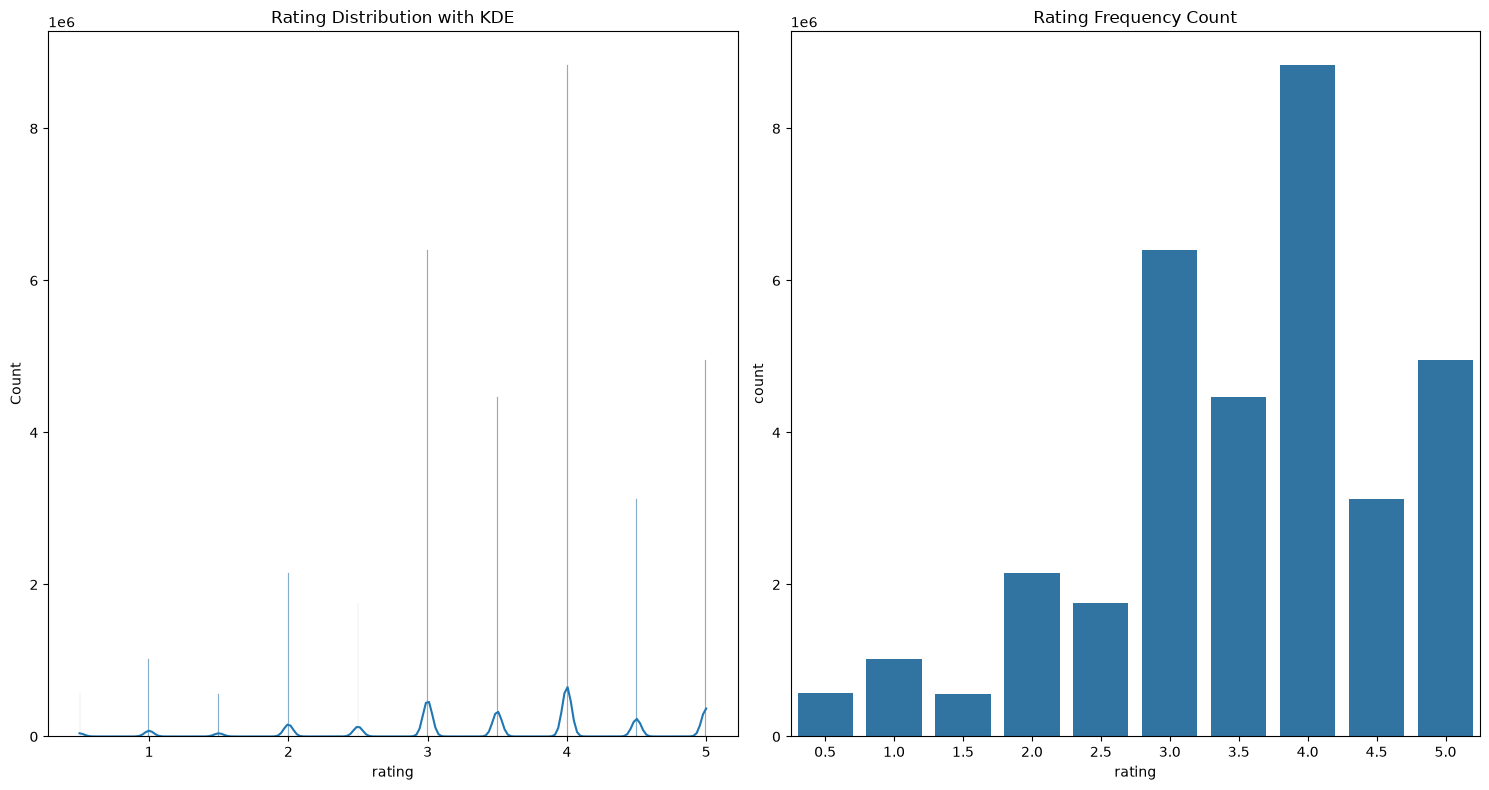

In [36]:
plt.figure(figsize=(15, 8))


plt.subplot(1, 2, 1)
sns.histplot(data=ratings, x='rating', kde=True)
plt.title("Rating Distribution with KDE")


plt.subplot(1, 2, 2)
sns.countplot(data=ratings, x='rating')
plt.title("Rating Frequency Count")

plt.tight_layout()
plt.show()

In [37]:
movie_rating_counts = ratings.groupby('movieId')['rating'].count()
movie_rating_counts.sort_values(ascending=False)

movieId
318       122296
356       113581
296       108756
2571      107056
593       101802
           ...  
230881         1
230877         1
230871         1
161700         1
288983         1
Name: rating, Length: 83239, dtype: int64

In [38]:
movie_rating_counts.describe()

count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
Name: rating, dtype: float64

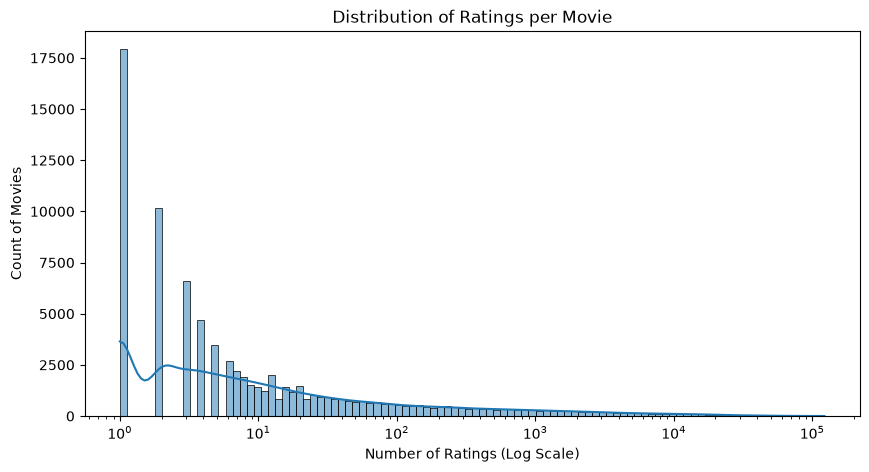

In [39]:
plt.figure(figsize=(10, 5))

# Log scale makes highly skewed distributions readable
sns.histplot(movie_rating_counts, kde=True, log_scale=True)

plt.xlabel("Number of Ratings (Log Scale)")
plt.ylabel("Count of Movies")
plt.title("Distribution of Ratings per Movie")
plt.show()


In [40]:
users_rating_counts = ratings.groupby('userId')['rating'].count()
users_rating_counts.sort_values(ascending=False)

userId
189614    33332
48766      9554
207216     9178
175998     9016
76618      8919
          ...  
118297        1
228609        1
159558        1
12701         1
104595        1
Name: rating, Length: 330975, dtype: int64

In [41]:
users_rating_counts.describe()

count    330975.00000
mean        102.21969
std         232.15453
min           1.00000
25%          15.00000
50%          31.00000
75%          98.00000
max       33332.00000
Name: rating, dtype: float64

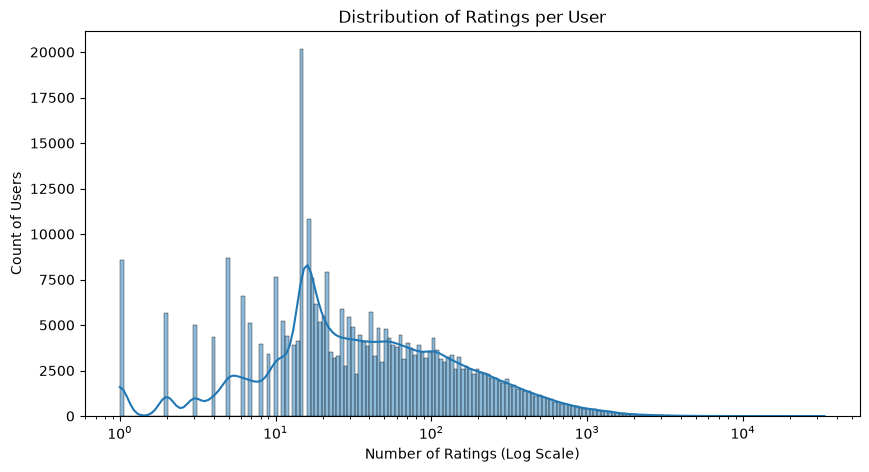

In [42]:
plt.figure(figsize=(10, 5))

# Log scale makes highly skewed distributions readable
sns.histplot(users_rating_counts, kde=True, log_scale=True)

plt.xlabel("Number of Ratings (Log Scale)")
plt.ylabel("Count of Users")
plt.title("Distribution of Ratings per User")
plt.show()

In [43]:
movie_counts = ratings.groupby('movieId')['rating'].count()
valid_movies = movie_counts[movie_counts >= 50].index
len(valid_movies)

16116

In [44]:
df_filtered_movies = ratings[ratings['movieId'].isin(valid_movies)]

df_filtered_movies

,userId,movieId,rating
0,1,1,4.0
1,1,110,4.0
2,1,158,4.0
3,1,260,4.5
4,1,356,5.0
...,...,...,...
33832157,330975,8340,2.0
33832158,330975,8493,2.5
33832159,330975,8622,4.0
33832160,330975,8665,3.0


In [45]:
user_counts_updated = df_filtered_movies.groupby('userId')['rating'].count()

In [46]:
user_counts_updated.describe()

count    330764.000000
mean        100.775511
std         214.532050
min           1.000000
25%          15.000000
50%          31.000000
75%          98.000000
max       12008.000000
Name: rating, dtype: float64

In [47]:
valid_users = user_counts_updated[user_counts_updated >= 50].index
len(valid_users)

130306

In [48]:
final_ratings = df_filtered_movies[df_filtered_movies['userId'].isin(valid_users)]

In [49]:
print("--- DATASET COMPARISON ---")
print(f"Original Rows: {len(ratings):,}")
print(f"Final Filtered Rows: {len(final_ratings):,}")
print(f"Rows Removed: {len(ratings) - len(final_ratings):,}\n")

print(f"Original Unique Movies: {ratings['movieId'].nunique():,}")
print(f"Final Unique Movies: {final_ratings['movieId'].nunique():,}\n")

print(f"Original Unique Users: {ratings['userId'].nunique():,}")
print(f"Final Unique Users: {final_ratings['userId'].nunique():,}")


--- DATASET COMPARISON ---
Original Rows: 33,832,162
Final Filtered Rows: 29,657,653
Rows Removed: 4,174,509

Original Unique Movies: 83,239
Final Unique Movies: 16,116

Original Unique Users: 330,975
Final Unique Users: 130,306


In [51]:
def calculate_sparsity(df):
	total_ratings = len(df)
	unique_users = df['userId'].nunique()
	unique_movies = df['movieId'].nunique()
	# Calculate matrix density first, then subtract from 1 for sparsity
	density = total_ratings / (unique_users * unique_movies)
	sparsity_percentage = (1 - density) * 100
	return sparsity_percentage

In [53]:
sparsity_before = calculate_sparsity(ratings)
sparsity_after = calculate_sparsity(final_ratings)

# --- DISPLAY RESULTS ---
print("--- MATRIX SPARSITY COMPARISON ---")
print(f"Original Sparsity: {sparsity_before:.4f}%")
print(f"Filtered Sparsity: {sparsity_after:.4f}%")
print(f"Improvement (Density Increase): {sparsity_before - sparsity_after:.4f}%")

--- MATRIX SPARSITY COMPARISON ---
Original Sparsity: 99.8772%
Filtered Sparsity: 98.5877%
Improvement (Density Increase): 1.2895%
